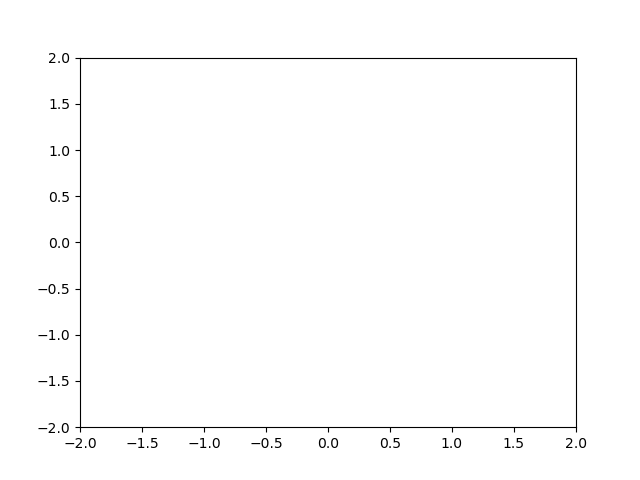

In [6]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
def generate_tesseract():
    vertices = []
    for x in [-1, 1]:
        for y in [-1, 1]:
            for z in [-1, 1]:
                for w in [-1, 1]:
                    vertices.append([x, y, z, w])
    return np.array(vertices)
def rotate_4d(points, angle):
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, c, -s],
        [0, 0, s, c]
    ])
    return points @ rotation_matrix.T
def project_4d_to_3d(points, distance=3):
    w = 1 / (distance - points[:, 3])
    projected = points[:, :3] * w[:, np.newaxis]
    return projected
def project_3d_to_2d(points, distance=5):
    z = 1 / (distance - points[:, 2])
    projected = points[:, :2] * z[:, np.newaxis]
    return projected
def get_edges(vertices):
    edges = []
    for i in range(len(vertices)):
        for j in range(i+1, len(vertices)):
            if np.sum(np.abs(vertices[i] - vertices[j])) == 2:
                edges.append((i, j))
    return edges
vertices_4d = generate_tesseract()
edges = get_edges(vertices_4d)

fig, ax = plt.subplots()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
lines = [ax.plot([], [], 'gold')[0] for _ in edges]
angle = 0
def update(frame):
    global angle
    angle += 0.03

    rotated = rotate_4d(vertices_4d, angle)
    proj3d = project_4d_to_3d(rotated)
    proj2d = project_3d_to_2d(proj3d)

    for line, (i, j) in zip(lines, edges):
        x = [proj2d[i, 0], proj2d[j, 0]]
        y = [proj2d[i, 1], proj2d[j, 1]]
        line.set_data(x, y)

    return lines

anim = FuncAnimation(fig, update, frames=200, interval=50)
plt.show()